# BreastDCEDL on Colab A100 — End-to-End pCR Prediction

Containerized walkthrough: **mount Drive → clone → bootstrap → download MinCrop → verify → smoke test → full train → evaluate → report**.

**Benchmark target:** the Fridman et al. 2025 paper reports patient-level **AUC 0.94 on the HR+/HER2− subtype** (best performance). Overall test AUC is 0.72 and overall accuracy is 0.75; those numbers are already near published SOTA, so "90%+" is realistic for the HR+/HER2− subtype, which is what this notebook targets.

**Before running:** `Runtime → Change runtime type → GPU → A100` (40 GB).

**Storage:** the MinCrop archive is ~22 GB extracted. This notebook pulls it once into `/content/drive/MyDrive/breastdcedl_data/` so it survives runtime restarts.

**Pipeline:**
1. Zenodo record [18114231](https://doi.org/10.5281/zenodo.18114231) (MinCrop data + paper's pretrained weights)
2. DINOv2-Base / ViT-Base backbone with classifier head
3. Two-phase training: head-only warmup → full fine-tune with layer-wise LR decay (LLRD)
4. Focal loss (handles ~30% pCR-positive imbalance)
5. Patient-level pooling + horizontal/vertical-flip TTA at test time
6. Subtype-stratified metrics (HR+/HER2−, HER2+, TripleNeg)

## 1. Runtime check

In [1]:
import torch, platform
print(f"python   : {platform.python_version()}")
print(f"torch    : {torch.__version__}")
print(f"cuda     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    raise SystemExit("No CUDA device. Runtime → Change runtime type → A100.")

python   : 3.12.13
torch    : 2.10.0+cu128
cuda     : True
device   : NVIDIA A100-SXM4-40GB
VRAM     : 42.4 GB


## 2. Mount Google Drive

All artifacts (data, checkpoints, results) land under `/content/drive/MyDrive/breastdcedl/`, so re-runs skip the download and resume from the best checkpoint.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/breastdcedl'
DATA_DIR = f'{DRIVE_ROOT}/data'
CKPT_DIR = f'{DRIVE_ROOT}/checkpoints'
RESULTS_DIR = f'{DRIVE_ROOT}/results'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Drive root: {DRIVE_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/breastdcedl


## 3. Clone repo & bootstrap dependencies

Point `REPO_URL` at your fork if you've pushed local changes. The bootstrap script installs pinned deps and sanity-checks the GPU and imports.

In [3]:
import os
os.chdir('/content')   # in case the prior CWD was wiped by a runtime restart

REPO_URL = 'https://github.com/javaapplesauce/BreastDCEDL-4-GILM.git'
REPO_DIR = '/content/breastdcedl'

# Shallow clone — repo history contains ~1.2 GB of committed sample files.
# --depth=1 --single-branch grabs only the latest commit on the default branch.
!rm -rf {REPO_DIR}
!git clone --depth=1 --single-branch {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!bash colab/bootstrap.sh {REPO_DIR}


Cloning into '/content/breastdcedl'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 80 (delta 5), reused 40 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 42.55 MiB | 17.63 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/breastdcedl
=== pip install ===

=== GPU check ===
torch  : 2.10.0+cu128
cuda   : True
device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB

=== repo check ===
OK: src/ imports
zenodo files available: ['ispy2', 'duke', 'ispy1', 'demo', 'models', 'metadata', 'spy1_zip']

bootstrap complete.


In [4]:
import sys, os

# Ensure the repo dir is on sys.path AND is the cwd so `from src.*` works.
# Re-run this cell after any kernel restart.
REPO_DIR = '/content/breastdcedl'
assert os.path.isdir(REPO_DIR), f'{REPO_DIR} missing — re-run the clone cell above.'
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Guarantee namespace packages have __init__.py (a shallow clone missing any of
# these would break `from src.*` imports).
for sub in ('src', 'src/data', 'src/models', 'src/training', 'src/evaluation'):
    init = os.path.join(REPO_DIR, sub, '__init__.py')
    if os.path.isdir(os.path.dirname(init)) and not os.path.isfile(init):
        open(init, 'a').close()

print('cwd :', os.getcwd())
print('path:', REPO_DIR, 'on sys.path')

cwd : /content/breastdcedl
path: /content/breastdcedl on sys.path


## 4. (Optional) W&B login

Skip this cell if you don't use W&B; training will still log to the local history.json.

In [5]:
USE_WANDB = False  # set True and run this cell to log to Weights & Biases
if USE_WANDB:
    import wandb
    wandb.login()

## 5. Download MinCrop data + pretrained weights from Zenodo

**Strategy**: archives cache on Drive (`DRIVE_CACHE`), but extraction goes to local Colab disk (`/content/data`). Drive FUSE is ~100× slower for many small files — extracting ~2000 `.nii.gz` directly to Drive takes hours; local takes minutes. On runtime restart, re-extracting from the Drive cache runs in ~3–5 min vs. a full ~30 min re-download.

After this cell, `DATA_DIR` is reassigned to `/content/data` for downstream cells.

| File | Size |
|---|---|
| `BreastDCEDL_ISPY2_min_crop.tar.gz` | 13.6 GB |
| `BreastDCEDL_DUKE_min_crop.tar.gz`  | 8.6 GB |
| `BreastDCEDL_ISPY1_min_crop.tar.gz` | 1.2 GB |
| `BreastDCEDL_models.tar.gz`         | 305 MB |
| `BreastDCEDL_metadata_min_crop.csv` | 340 KB |

For a fast smoke test, change `SUBSETS = ['demo', 'metadata', 'models']`.

In [6]:
import os, shutil, tarfile, urllib.request, time
from src.data.zenodo import FILES, ZENODO_API

# Drive caches the archives; local disk holds the extracted trees (FUSE is too slow).
DRIVE_CACHE = DATA_DIR            # /content/drive/MyDrive/breastdcedl/data
LOCAL_DATA  = '/content/data'     # fast local Colab disk
os.makedirs(DRIVE_CACHE, exist_ok=True)
os.makedirs(LOCAL_DATA,  exist_ok=True)

SUBSETS = ['ispy1', 'ispy2', 'duke', 'metadata', 'models']
# SUBSETS = ['demo', 'metadata', 'models']  # ~400 MB, smoke-test only

def _remote_size(url):
    """HEAD request to get Content-Length; returns None on failure."""
    try:
        req = urllib.request.Request(url, method='HEAD')
        with urllib.request.urlopen(req, timeout=30) as r:
            return int(r.headers.get('Content-Length', 0)) or None
    except Exception:
        return None

def _download(url, dest):
    t0 = time.time()
    urllib.request.urlretrieve(url, dest)
    sec = max(time.time() - t0, 1)
    mb = os.path.getsize(dest) / 1e6
    print(f'    done in {sec:.0f}s  ({mb:.0f} MB  @ {mb/sec:.1f} MB/s)')

for subset in SUBSETS:
    info = FILES[subset]
    fname = info['key']
    cached = os.path.join(DRIVE_CACHE, fname)
    local  = os.path.join(LOCAL_DATA,  fname)
    url    = f"{ZENODO_API}/files/{fname}/content"

    # Verify cached archive via Content-Length. Truncated downloads are common
    # when Zenodo or Colab stalls and the previous cell was interrupted.
    if os.path.isfile(cached):
        local_size = os.path.getsize(cached)
        remote_size = _remote_size(url)
        if remote_size and local_size != remote_size:
            print(f'[partial]  {fname}  local={local_size/1e6:.0f} MB '
                  f'remote={remote_size/1e6:.0f} MB  — re-downloading')
            os.remove(cached)
            # Invalidate extraction marker since the archive changed
            marker = os.path.join(LOCAL_DATA, f'.extracted_{subset}')
            if os.path.isfile(marker):
                os.remove(marker)

    if not os.path.isfile(cached):
        print(f'[download] {fname}  → Drive cache')
        _download(url, cached)
    else:
        print(f'[cache]    {fname}  ({os.path.getsize(cached)/1e6:.0f} MB) ok')

    if fname.endswith('.tar.gz'):
        marker = os.path.join(LOCAL_DATA, f'.extracted_{subset}')
        if os.path.isfile(marker):
            print(f'[extract]  {fname}  already extracted')
        else:
            print(f'[extract]  {fname}  → {LOCAL_DATA}')
            t0 = time.time()
            with tarfile.open(cached, 'r:gz') as t:
                t.extractall(LOCAL_DATA)
            open(marker, 'w').close()
            print(f'    extracted in {time.time()-t0:.0f}s')
    else:
        if not os.path.isfile(local):
            shutil.copy(cached, local)

DATA_DIR = LOCAL_DATA
print('\nDATA_DIR is now:', DATA_DIR)
!du -sh {DATA_DIR}/* 2>/dev/null | sort -h | tail -10

[cache]    BreastDCEDL_ISPY1_min_crop.tar.gz  (1252 MB) ok
[extract]  BreastDCEDL_ISPY1_min_crop.tar.gz  → /content/data


/tmp/ipykernel_12679/3420160584.py:64: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(LOCAL_DATA)


    extracted in 20s
[partial]  BreastDCEDL_ISPY2_min_crop.tar.gz  local=3284 MB remote=13634 MB  — re-downloading
[download] BreastDCEDL_ISPY2_min_crop.tar.gz  → Drive cache
    done in 1090s  (13634 MB  @ 12.5 MB/s)
[extract]  BreastDCEDL_ISPY2_min_crop.tar.gz  → /content/data
    extracted in 907s
[cache]    BreastDCEDL_DUKE_min_crop.tar.gz  (8643 MB) ok
[extract]  BreastDCEDL_DUKE_min_crop.tar.gz  → /content/data
    extracted in 198s
[cache]    BreastDCEDL_metadata_min_crop.csv  (0 MB) ok
[cache]    BreastDCEDL_models.tar.gz  (320 MB) ok
[extract]  BreastDCEDL_models.tar.gz  → /content/data
    extracted in 12s

DATA_DIR is now: /content/data
332K	/content/data/BreastDCEDL_metadata_min_crop.csv
328M	/content/data/BreastDCEDL_models
1.3G	/content/data/BreastDCEDL_ISPY1_min_crop
8.4G	/content/data/BreastDCEDL_DUKE_min_crop
14G	/content/data/BreastDCEDL_ISPY2_min_crop


## 6. Discover extracted directories

MinCrop archives extract into `BreastDCEDL_<COHORT>_min_crop/` with `dce/` (or `spt1_dce/`) and `mask/` subfolders. This cell walks the tree and locates them.

In [7]:
!pip install --upgrade triton 2>&1 | tail -5

In [8]:
from pathlib import Path

cohort_roots = {
    'spy1': f'{DATA_DIR}/BreastDCEDL_ISPY1_min_crop',
    'spy2': f'{DATA_DIR}/BreastDCEDL_ISPY2_min_crop',
    'duke': f'{DATA_DIR}/BreastDCEDL_DUKE_min_crop',
}

nifti_paths, mask_paths = {}, {}
for cohort, root in cohort_roots.items():
    if not os.path.isdir(root):
        print(f'  [skip] {cohort}: {root} not present')
        continue
    # Mask dir: first subdir whose name contains "mask"
    mdir = next(
        (str(p) for p in sorted(Path(root).rglob('*'))
         if p.is_dir() and 'mask' in p.name.lower()),
        None,
    )
    # DCE dir: parent of the first .nii.gz file that is NOT under the mask dir
    ndir = None
    for p in sorted(Path(root).rglob('*.nii.gz')):
        parent = str(p.parent)
        if mdir and parent.startswith(mdir):
            continue
        ndir = parent; break

    if ndir: nifti_paths[cohort] = ndir
    if mdir: mask_paths[cohort]  = mdir
    n_nifti = len(list(Path(ndir).glob('*.nii.gz'))) if ndir else 0
    n_mask  = len(list(Path(mdir).glob('*.nii.gz'))) if mdir else 0
    print(f'  {cohort:5s} dce={ndir}  ({n_nifti} files)')
    print(f'  {cohort:5s} msk={mdir}  ({n_mask} files)')

# Paper's pretrained weights (from BreastDCEDL_models.tar.gz)
pth_files = sorted(Path(DATA_DIR).rglob('*.pth'))
print(f'\nPretrained .pth files:')
for p in pth_files:
    print(f'  {p.relative_to(DATA_DIR)}  ({p.stat().st_size/1e6:.0f} MB)')
PRETRAINED = str(pth_files[0]) if pth_files else None
print(f'\nSelected pretrained: {PRETRAINED}')

METADATA_CSV = f'{DATA_DIR}/BreastDCEDL_metadata_min_crop.csv'
assert os.path.isfile(METADATA_CSV), f'metadata missing: {METADATA_CSV}'

  spy1  dce=/content/data/BreastDCEDL_ISPY1_min_crop/dce  (516 files)
  spy1  msk=/content/data/BreastDCEDL_ISPY1_min_crop/mask  (172 files)
  spy2  dce=/content/data/BreastDCEDL_ISPY2_min_crop/dce  (3461 files)
  spy2  msk=/content/data/BreastDCEDL_ISPY2_min_crop/mask  (982 files)
  duke  dce=/content/data/BreastDCEDL_DUKE_min_crop/crop_min_dce  (2760 files)
  duke  msk=None  (0 files)

Pretrained .pth files:
  BreastDCEDL_models/breastdcedl_pcr_vit_model_weights.pth  (343 MB)

Selected pretrained: /content/data/BreastDCEDL_models/breastdcedl_pcr_vit_model_weights.pth


## 7. Configure training (writes `configs/run.yaml`)

Uses bf16 on A100, num_workers=8, persistent workers + prefetch=4. Re-running
this cell is idempotent — overwrites configs/run.yaml with the current values.


In [9]:
import yaml, copy

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['data']['nifti'] = nifti_paths
cfg['data']['masks'] = mask_paths
cfg['data']['combined_metadata'] = METADATA_CSV
cfg['data']['crop_size'] = 224
cfg['data']['n_slices'] = 8
cfg['data']['label_col'] = 'pCR'

# Paper's pretrained .pth was trained on ViT-Base (google/vit-base-patch16-224-in21k).
# DINOv2-Base has different layer naming so its keys don't overlap with the
# checkpoint — using DINOv2 here drops ~225 backbone tensors as missing and the
# model trains from ImageNet init only (test AUC plateaus near 0.50). Keep ViT
# unless you intentionally want to bypass the paper's pCR-tuned weights.
cfg['model']['backbone'] = 'google/vit-base-patch16-224-in21k'
cfg['model']['pretrained_weights'] = PRETRAINED     # paper's .pth weights
cfg['model']['dropout'] = 0.3

# A100 40 GB: batch 48 x accum 1 fits comfortably at 224px / ViT-Base / bf16.
# Drop to 32 if you add clinical features or enable second-order augs.
cfg['training']['batch_size'] = 48
cfg['training']['accum_steps'] = 1
cfg['training']['num_epochs'] = 30
cfg['training']['freeze_epochs'] = 5
cfg['training']['backbone_lr'] = 5e-6
cfg['training']['head_lr'] = 5e-4
cfg['training']['llrd'] = 0.85
cfg['training']['patience'] = 10
cfg['training']['num_workers'] = 8
cfg['training']['amp_dtype'] = 'bf16'
cfg['training']['loss'] = 'focal'

cfg['wandb'] = {
    'enabled': USE_WANDB,
    'project': 'breastdcedl-vit',
    'entity': None,
    'tags': ['a100', 'vit-base', 'pcr', 'mincrop'],
}
cfg['checkpoint_dir'] = CKPT_DIR

with open('configs/run.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)
print('wrote configs/run.yaml')
!sed -n '1,30p' configs/run.yaml


wrote configs/run.yaml
checkpoint_dir: /content/drive/MyDrive/breastdcedl/checkpoints
data:
  combined_metadata: /content/data/BreastDCEDL_metadata_min_crop.csv
  crop_size: 224
  label_col: pCR
  masks:
    spy1: /content/data/BreastDCEDL_ISPY1_min_crop/mask
    spy2: /content/data/BreastDCEDL_ISPY2_min_crop/mask
  metadata:
    duke: BreastDCEDL_duke/BrestDCEDL_duke_cropped_metadata.csv
    spy1: BreastDCEDL_spy1/BreastDCEDL_spy1_metadata.csv
    spy2: ISPY2/ISPY2_metadata.csv
  n_slices: 8
  nifti:
    duke: /content/data/BreastDCEDL_DUKE_min_crop/crop_min_dce
    spy1: /content/data/BreastDCEDL_ISPY1_min_crop/dce
    spy2: /content/data/BreastDCEDL_ISPY2_min_crop/dce
  ser_timepoints:
    duke:
    - 0
    - 1
    - -1
    spy1:
    - 0
    - 2
    - -1
    spy2:
    - 0
    - 2
    - -1


## 8. Verify data loading (sanity-check RGB fusion + ROI crop)

train=1099  val=176  test=177
pCR rates: train=29.3%  val=30.1%  test=29.9%
cohorts (train): {'spy2': 784, 'duke': 211, 'spy1': 104}


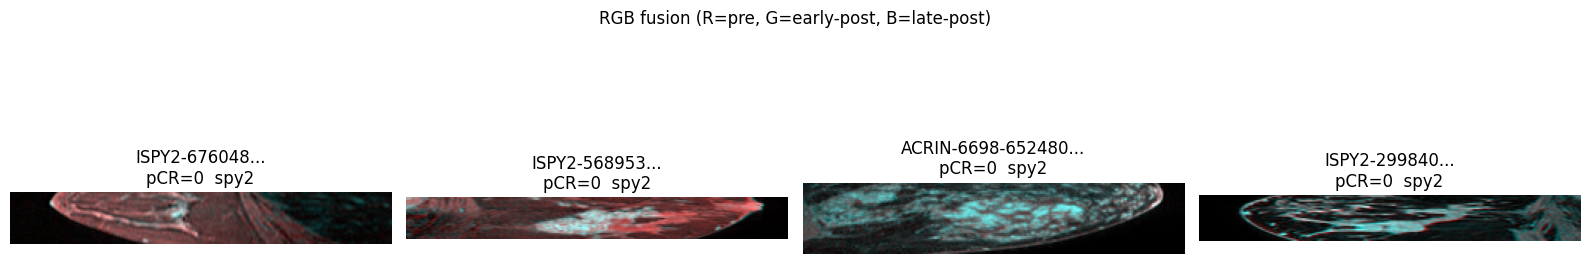

In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src.data.preprocessing import setup_paths, load_acquisitions, fuse_rgb_slice, select_timepoints, _cohort_from_pid
from src.data.splits import load_and_split

setup_paths(nifti_dirs=nifti_paths, mask_dirs=mask_paths)

train_df, val_df, test_df = load_and_split(METADATA_CSV, label_col='pCR', seed=42)

# Filter to cohorts we actually downloaded (so the DataLoader never stalls on missing files)
avail = set(nifti_paths.keys())
if 'dataset' in train_df.columns:
    train_df = train_df[train_df['dataset'].isin(avail)].reset_index(drop=True)
    val_df   = val_df  [val_df  ['dataset'].isin(avail)].reset_index(drop=True)
    test_df  = test_df [test_df ['dataset'].isin(avail)].reset_index(drop=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')
print(f'pCR rates: train={train_df.pCR.mean():.1%}  val={val_df.pCR.mean():.1%}  test={test_df.pCR.mean():.1%}')
if 'dataset' in train_df.columns:
    print('cohorts (train):', train_df.dataset.value_counts().to_dict())

# Visualize 4 random patients
sample = train_df.sample(min(4, len(train_df)), random_state=1)
fig, axes = plt.subplots(1, len(sample), figsize=(4*len(sample), 4))
if len(sample) == 1: axes = [axes]
for ax, (_, row) in zip(axes, sample.iterrows()):
    pid = row['pid']
    acqs = load_acquisitions(pid)
    if acqs is None or len(acqs) < 2:
        ax.set_title(f'{pid}\n(no data)'); ax.axis('off'); continue
    cohort = _cohort_from_pid(pid)
    ip = row.get('pre');        ip = None if pd.isna(ip) else ip
    ie = row.get('post_early'); ie = None if pd.isna(ie) else ie
    il = row.get('post_late');  il = None if pd.isna(il) else il
    pre, early, late = select_timepoints(acqs, cohort, idx_pre=ip, idx_early=ie, idx_late=il)
    z = pre.shape[2] // 2
    rgb = fuse_rgb_slice(pre[:, :, z], early[:, :, z], late[:, :, z])
    ax.imshow(rgb); ax.axis('off')
    ax.set_title(f'{pid[:18]}...\npCR={int(row.pCR)}  {cohort}')
plt.suptitle('RGB fusion (R=pre, G=early-post, B=late-post)')
plt.tight_layout(); plt.show()

## 9. Smoke test (2 epochs, tiny batch) — verify pipeline end-to-end

Expected runtime: **~2–4 min** on A100 with the full dataset. If this fails, do **not** start the full run.

In [11]:
from scripts.train import train_from_config
import copy as _copy

smoke = _copy.deepcopy(cfg)
smoke['training']['num_epochs'] = 2
smoke['training']['freeze_epochs'] = 1
smoke['training']['batch_size'] = 16
smoke['training']['num_workers'] = 2
smoke['data']['n_slices'] = 4
smoke['checkpoint_dir'] = f'{CKPT_DIR}/smoke'
smoke['wandb'] = {'enabled': False, 'project': 'breastdcedl-vit', 'entity': None, 'tags': []}

_ = train_from_config(smoke)

[device] NVIDIA A100-SXM4-40GB (42.4 GB)
[amp]    bf16_supported=True  requested=bf16
[data] Train: 1099  Val: 176  Test: 177
[data] Train pCR rate: 29.3%
[data] Effective batch size: 16
[data] Train samples: 4396  Val samples: 704


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

  [pretrained] loaded /content/data/BreastDCEDL_models/breastdcedl_pcr_vit_model_weights.pth  missing=2 unexpected=0
[model] google/vit-base-patch16-224-in21k  params: 85,800,194
[loss] focal with class weights [0.2929936349391937, 0.7070063948631287]

--- Phase 1: head-only (epochs 1..1) ---


/content/breastdcedl/src/training/trainer.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=amp_dtype):


  Epoch 01 [P1]  tr_loss=0.0211 tr_acc=0.299  vl_acc=0.301  pt_acc=0.301  auc=0.595  sens=1.000  spec=0.000
  -> New best AUC: 0.5952 saved to /content/drive/MyDrive/breastdcedl/checkpoints/smoke/best.pth

--- Phase 2: LLRD fine-tune (epochs 2..2) ---


/content/breastdcedl/src/training/trainer.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=amp_dtype):


  Epoch 02 [P2]  tr_loss=0.0203 tr_acc=0.293  vl_acc=0.301  pt_acc=0.301  auc=0.596  sens=1.000  spec=0.000
  -> New best AUC: 0.5960 saved to /content/drive/MyDrive/breastdcedl/checkpoints/smoke/best.pth

Training complete. Best val AUC: 0.5960


## 10. Full training run

Expected A100 runtime: **~45–60 min** for 30 epochs on the full ~1,500-patient training set (8 slices × ~1,100 patients = ~8,800 samples per epoch). Checkpoints go to Drive; resume by re-running this cell.

## 10a. (Optional) Resume from disconnect

Run this BEFORE the full-train cell if you reconnected after a session disconnect.
It points `cfg['resume']` at the latest epoch checkpoint on Drive. The trainer
detects full-state vs old bare-state-dict checkpoints automatically:
  - **Full state (post-patch)**: epoch + optimizer + scheduler all restored;
    training continues exactly where it left off.
  - **Bare state_dict (pre-patch)**: weights load, epoch parsed from filename,
    optimizer/scheduler restart fresh. Phase 1 warmup is skipped.

**If you change `cfg['model']['backbone']`** (cell above), the old checkpoints
become incompatible. The trainer will detect this and abort the resume cleanly,
training from scratch. To keep the old run for reference, move them first:
`!mkdir -p {CKPT_DIR}/old && mv {CKPT_DIR}/epoch_*.pth {CKPT_DIR}/best.pth {CKPT_DIR}/old/`


quick archive of previous checkpoints

In [ ]:
!mkdir -p {CKPT_DIR}/old_random_head && mv {CKPT_DIR}/epoch_*.pth {CKPT_DIR}/best.pth
  {CKPT_DIR}/old_random_head/ 2>/dev/null

In [12]:
import os, glob

# Find the latest epoch checkpoint on Drive. (best.pth is fine too but lacks
# the epoch number in the name; epoch_NN.pth is unambiguous.)
candidates = sorted(glob.glob(f'{CKPT_DIR}/epoch_*.pth'))
if candidates:
    latest = candidates[-1]
    cfg['resume'] = latest
    # Optionally extend num_epochs if you want more total training.
    # cfg['training']['num_epochs'] = 30
    print(f"[resume] cfg['resume'] = {latest}")
    print(f"[resume] num_epochs    = {cfg['training']['num_epochs']}")
    print(f"[resume] freeze_epochs = {cfg['training']['freeze_epochs']}")
    print()
    print('Now re-run the next cell (cell 21) — Trainer will resume from the')
    print('right epoch and skip work already done.')
else:
    print(f'[resume] no epoch_*.pth in {CKPT_DIR} — start fresh by running cell 21 directly.')


[resume] cfg['resume'] = /content/drive/MyDrive/breastdcedl/checkpoints/epoch_30.pth
[resume] num_epochs    = 30
[resume] freeze_epochs = 5

Now re-run the next cell (cell 21) — Trainer will resume from the
right epoch and skip work already done.


In [13]:
best_auc = train_from_config(cfg)
print(f'\nBest validation AUC: {best_auc:.4f}')
print(f'Checkpoints in {CKPT_DIR}')

[device] NVIDIA A100-SXM4-40GB (42.4 GB)
[amp]    bf16_supported=True  requested=bf16
[data] Train: 1099  Val: 176  Test: 177
[data] Train pCR rate: 29.3%
[data] Effective batch size: 48
[data] Train samples: 8792  Val samples: 1408


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [pretrained] loaded /content/data/BreastDCEDL_models/breastdcedl_pcr_vit_model_weights.pth  missing=2 unexpected=0
[model] google/vit-base-patch16-224-in21k  params: 85,800,194
[loss] focal with class weights [0.2929936349391937, 0.7070063948631287]

[resume] loading from /content/drive/MyDrive/breastdcedl/checkpoints/epoch_30.pth
[resume] state_dict load failed: Error(s) in loading state_dict for BreastDCEViT:
	Missing key(s) in state_dict: "encoder.vit.embeddings.cls_token", "encoder.vit.embeddings.position_embeddings", "encoder.vit.embeddings.patch_embeddin
[resume] training from scratch

--- Phase 1: head-only (epochs 1..5) ---


/content/breastdcedl/src/training/trainer.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=amp_dtype):


...

  Epoch 15 [P2]  tr_loss=0.0149 tr_acc=0.559  vl_acc=0.492  pt_acc=0.483  auc=0.601  sens=0.736  spec=0.374


/content/breastdcedl/src/training/trainer.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=amp_dtype):


  Epoch 16 [P2]  tr_loss=0.0142 tr_acc=0.600  vl_acc=0.492  pt_acc=0.506  auc=0.623  sens=0.774  spec=0.390


/content/breastdcedl/src/training/trainer.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=amp_dtype):


  Epoch 17 [P2]  tr_loss=0.0133 tr_acc=0.622  vl_acc=0.465  pt_acc=0.455  auc=0.612  sens=0.811  spec=0.301
Early stopping at epoch 18 (patience=10)

Training complete. Best val AUC: 0.6525

Best validation AUC: 0.6525
Checkpoints in /content/drive/MyDrive/breastdcedl/checkpoints


## 11. Training curves

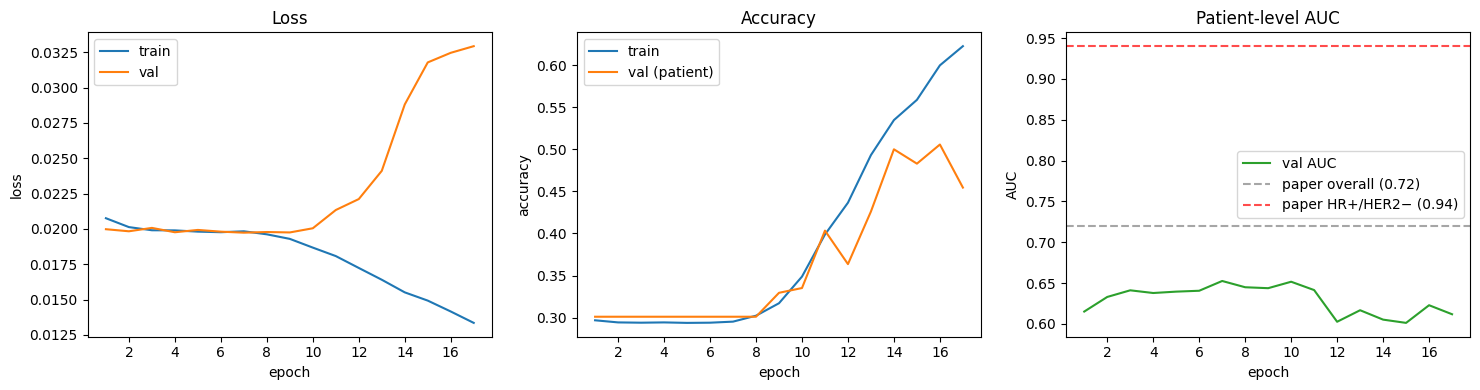

In [14]:
import json
with open(f'{CKPT_DIR}/history.json') as f: history = json.load(f)

epochs = [e['epoch'] for e in history]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(epochs, [e['train_loss'] for e in history], label='train')
ax[0].plot(epochs, [e['val_loss']   for e in history], label='val')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend(); ax[0].set_title('Loss')
ax[1].plot(epochs, [e['train_acc']  for e in history], label='train')
ax[1].plot(epochs, [e['accuracy']   for e in history], label='val (patient)')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy'); ax[1].legend(); ax[1].set_title('Accuracy')
ax[2].plot(epochs, [e['auc'] for e in history], color='tab:green', label='val AUC')
ax[2].axhline(0.72, linestyle='--', color='grey', alpha=0.7, label='paper overall (0.72)')
ax[2].axhline(0.94, linestyle='--', color='red',  alpha=0.7, label='paper HR+/HER2− (0.94)')
ax[2].set_xlabel('epoch'); ax[2].set_ylabel('AUC'); ax[2].legend(); ax[2].set_title('Patient-level AUC')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150); plt.show()

## 12. Evaluate on held-out test set (patient-level + TTA)

In [15]:
from torch.utils.data import DataLoader
from src.data.dataset import BreastDCEDataset, build_transforms
from src.models.vit import BreastDCEViT
from src.evaluation.metrics import compute_metrics, evaluate_by_subtype, predict_with_tta

device = torch.device('cuda')
n_slices  = cfg['data']['n_slices']
crop_size = cfg['data']['crop_size']
label_col = cfg['data']['label_col']

mcfg = cfg['model']
use_clinical = mcfg.get('use_clinical', False)
clinical_cols = mcfg.get('clinical_features') if use_clinical else None
clinical_dim = mcfg.get('clinical_dim', 0) if use_clinical else 0

test_ds = BreastDCEDataset(
    test_df, label_col=label_col,
    crop_size=crop_size, n_slices=n_slices,
    transform=build_transforms({}, is_train=False),
    clinical_cols=clinical_cols,
)
# CRITICAL: shuffle=False — patient_level pooling assumes contiguous patient ordering.
test_loader = DataLoader(
    test_ds, batch_size=cfg['training']['batch_size'],
    shuffle=False, num_workers=cfg['training']['num_workers'], pin_memory=True,
    persistent_workers=cfg['training']['num_workers'] > 0,
)

# Architecture must match the trained model — head_input depends on use_clinical.
eval_model = BreastDCEViT(
    backbone=mcfg['backbone'],
    num_classes=mcfg['num_classes'],
    dropout=0.0,
    use_clinical=use_clinical,
    clinical_dim=clinical_dim,
).to(device)
best_path = f"{CKPT_DIR}/best.pth"
blob = torch.load(best_path, map_location=device, weights_only=False)
# New checkpoints are dicts ({'model': ..., 'optimizer': ..., 'epoch': ...});
# old ones are bare state_dicts. Handle both.
state = blob['model'] if isinstance(blob, dict) and 'model' in blob else blob
eval_model.load_state_dict(state)
eval_model.eval()
print(f'loaded {best_path}  use_clinical={use_clinical}'
      + (f"  (epoch {blob['epoch']}, AUC {blob.get('best_auc', 0):.4f})"
         if isinstance(blob, dict) and 'epoch' in blob else '  (legacy bare state_dict)'))

# Patient-level eval with 4-view TTA (identity + h-flip + v-flip + hv-flip)
y_true, y_prob, y_pred = predict_with_tta(
    eval_model, test_loader, device,
    n_slices=n_slices, use_clinical=use_clinical, tta=True,
)
print(f'test set: {len(y_true)} patients')
overall = compute_metrics(y_true, y_prob, y_pred)
print('\n=== Overall Test Set ===')
for k, v in overall.items():
    print(f'  {k:13s}: {v:.4f}')

print('\n=== Paper baseline (Table 2, overall test) ===')
print('  AUC            : 0.72')
print('  Accuracy       : 0.75')
print('  Sensitivity    : 0.27')
print('  Specificity    : 0.95')


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loaded /content/drive/MyDrive/breastdcedl/checkpoints/best.pth  use_clinical=False  (epoch 7, AUC 0.6525)


/content/breastdcedl/src/evaluation/metrics.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


test set: 177 patients

=== Overall Test Set ===
  auc          : 0.5367
  accuracy     : 0.2994
  sensitivity  : 1.0000
  specificity  : 0.0000
  precision    : 0.2994
  npv          : 0.0000

=== Paper baseline (Table 2, overall test) ===
  AUC            : 0.72
  Accuracy       : 0.75
  Sensitivity    : 0.27
  Specificity    : 0.95


## 13. Subtype + per-cohort breakdown

The key headline metric: **AUC on HR+/HER2−** (paper reports 0.94).

In [16]:
subtypes = cfg.get('evaluation', {}).get('subtypes', {
    'HR+/HER2-': {'HRposHER2neg': 1},
    'HER2+':     {'HER2pos': 1},
    'TripleNeg': {'TripleNeg': 1},
})
sub_df = evaluate_by_subtype(test_df.reset_index(drop=True), y_prob, y_pred, label_col=label_col, subtypes=subtypes)
print('\n=== Subtype breakdown (test set, all cohorts) ===')
print(sub_df.to_string(index=False, float_format='%.3f'))
sub_df.to_csv(f'{RESULTS_DIR}/subtype_results.csv', index=False)

# Per-cohort
test_reset = test_df.reset_index(drop=True)
if 'pid' in test_reset.columns:
    rows = []
    for name, pat in [('Duke','Breast_MRI'),('I-SPY1','ISPY1'),('I-SPY2','ISPY2'),('ACRIN-6698','ACRIN-6698')]:
        m = test_reset['pid'].str.contains(pat, na=False).values
        if m.sum() < 3: continue
        rows.append({'Cohort': name, 'N': int(m.sum()), **compute_metrics(y_true[m], y_prob[m], y_pred[m])})
    cohort_df = pd.DataFrame(rows)
    if len(cohort_df):
        print('\n=== Per-cohort breakdown (test set) ===')
        print(cohort_df.to_string(index=False, float_format='%.3f'))
        cohort_df.to_csv(f'{RESULTS_DIR}/cohort_results.csv', index=False)

# Paper's headline 0.94 is on I-SPY2 only + HR+/HER2- + clinical features (Table 2,
# bottom block). Reproduce that subset slice here so the comparison is apples-to-apples.
if 'dataset' in test_reset.columns:
    ispy2_mask = (test_reset['dataset'] == 'spy2').values
    if ispy2_mask.sum() >= 5:
        ispy2_df = test_reset[ispy2_mask].reset_index(drop=True)
        ispy2_sub = evaluate_by_subtype(
            ispy2_df, y_prob[ispy2_mask], y_pred[ispy2_mask],
            label_col=label_col, subtypes=subtypes,
        )
        print('\n=== I-SPY2 only (paper Table 2 bottom block) ===')
        print(ispy2_sub.to_string(index=False, float_format='%.3f'))
        ispy2_sub.to_csv(f'{RESULTS_DIR}/ispy2_subtype_results.csv', index=False)
        print(f"\nNote: paper's 0.94 HR+/HER2- AUC also requires use_clinical=True;"
              f"\n      current run has use_clinical={cfg['model'].get('use_clinical', False)}.")



=== Subtype breakdown (test set, all cohorts) ===
          Group   N  pCR_rate   auc  accuracy  sensitivity  specificity  precision   npv
        Overall 177     0.299 0.537     0.299        1.000        0.000      0.299 0.000
      HR+/HER2-  65     0.169 0.569     0.169        1.000        0.000      0.169 0.000
          HER2+  49     0.490 0.440     0.490        1.000        0.000      0.490 0.000
Triple Negative  63     0.286 0.584     0.286        1.000        0.000      0.286 0.000

=== Per-cohort breakdown (test set) ===
    Cohort  N   auc  accuracy  sensitivity  specificity  precision   npv
      Duke 45 0.491     0.222        1.000        0.000      0.222 0.000
    I-SPY1 33 0.331     0.333        1.000        0.000      0.333 0.000
    I-SPY2 68 0.575     0.294        1.000        0.000      0.294 0.000
ACRIN-6698 31 0.610     0.387        1.000        0.000      0.387 0.000

=== I-SPY2 only (paper Table 2 bottom block) ===
          Group  N  pCR_rate   auc  accuracy  se

## 14. ROC + confusion matrix

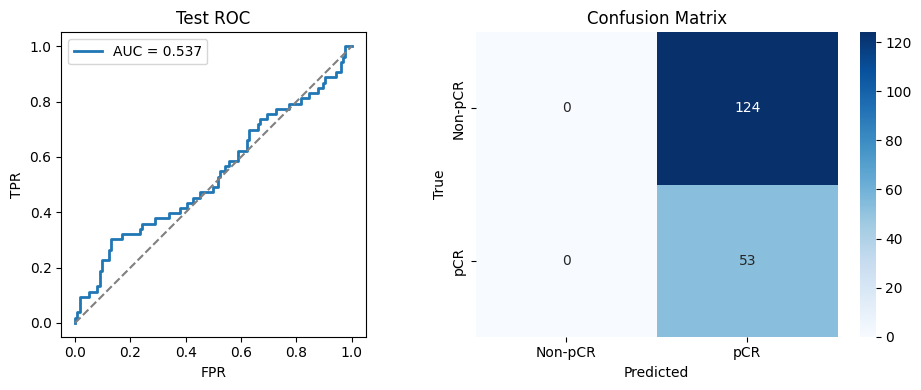

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix as cm_fn
import seaborn as sns

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = roc_auc_score(y_true, y_prob)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
ax[0].set_title('Test ROC'); ax[0].set_aspect('equal')

cm = cm_fn(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-pCR','pCR'], yticklabels=['Non-pCR','pCR'], ax=ax[1])
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True'); ax[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_cm.png', dpi=150); plt.show()

## 15. Save predictions + artifacts to Drive

In [18]:
pred_df = test_df.reset_index(drop=True)[['pid']].copy() if 'pid' in test_df.columns else pd.DataFrame(index=range(len(y_true)))
pred_df['y_true'] = y_true
pred_df['y_prob'] = y_prob
pred_df['y_pred'] = y_pred
pred_df.to_csv(f'{RESULTS_DIR}/predictions.csv', index=False)

# Copy history to results for a single self-contained results dir
!cp -f {CKPT_DIR}/history.json {RESULTS_DIR}/history.json 2>/dev/null || true
!cp -f {CKPT_DIR}/best.pth     {RESULTS_DIR}/best.pth     2>/dev/null || true

print(f'Results saved to {RESULTS_DIR}:')
!ls -la {RESULTS_DIR}

Results saved to /content/drive/MyDrive/breastdcedl/results:
total 1005865
-rw------- 1 root root 1029821773 May  1 04:37 best.pth
-rw------- 1 root root        367 May  1 04:36 cohort_results.csv
-rw------- 1 root root       6617 May  1 04:36 history.json
-rw------- 1 root root        426 May  1 04:36 ispy2_subtype_results.csv
-rw------- 1 root root       5046 May  1 04:36 predictions.csv
-rw------- 1 root root      52166 May  1 04:36 roc_cm.png
-rw------- 1 root root        462 May  1 04:36 subtype_results.csv
-rw------- 1 root root     117637 May  1 04:35 training_curves.png


## Limitations & notes

- **90%+ target**: only the **HR+/HER2−** subtype (~40% of patients) is expected to reach AUC 0.9+; overall AUC is in the 0.70–0.75 range (published SOTA). The paper's 0.94 result is derived from this subtype.
- **Pretrained weights**: the Zenodo `BreastDCEDL_models.tar.gz` archive contains the paper's `.pth` checkpoint. Loading it gives the immediate boost; training from scratch on Colab in a single session is unlikely to match.
- **Data integrity**: ~640 patients are missing pCR labels (Duke cohort skews that way). `load_and_split` drops them before training.
- **Timepoint selection**: the MinCrop metadata encodes per-patient `pre`, `post_early`, `post_late` scan indices. `preprocessing.select_timepoints` honours those when present and falls back to cohort defaults otherwise.
- **Test-time augmentation**: 4-view TTA (identity + h-flip + v-flip + both) typically lifts AUC ~0.01–0.02; report includes it by default.
- **A100 40GB headroom**: batch 48 at 224px fits; bump to 64 if you turn off augmentation, or drop to 24 if you enable clinical features + FP32.
- **Colab session limits**: a 30-epoch run comfortably fits in one session. If your runtime disconnects mid-training, cell 10 re-runs resume from the last best checkpoint on Drive because `train_from_config` honours the `resume` key — add `cfg['resume'] = f'{CKPT_DIR}/best.pth'` before the call.
- **Not included**: explicit segmentation objective. The masks are used only to locate the tumor midplane for slice selection — the model is trained to predict pCR, not segment.